In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

train_data.head()                        

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
survived = train_data["Survived"]

train_data = train_data.drop(["Survived"], axis = 1)

train_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
train_idx = train_data["PassengerId"]
test_idx = test_data["PassengerId"]

combined_data = pd.concat([train_data, test_data]).reset_index(drop=True)

combined_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
print("Null Values: ")
print(combined_data.isnull().sum())

Null Values: 
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


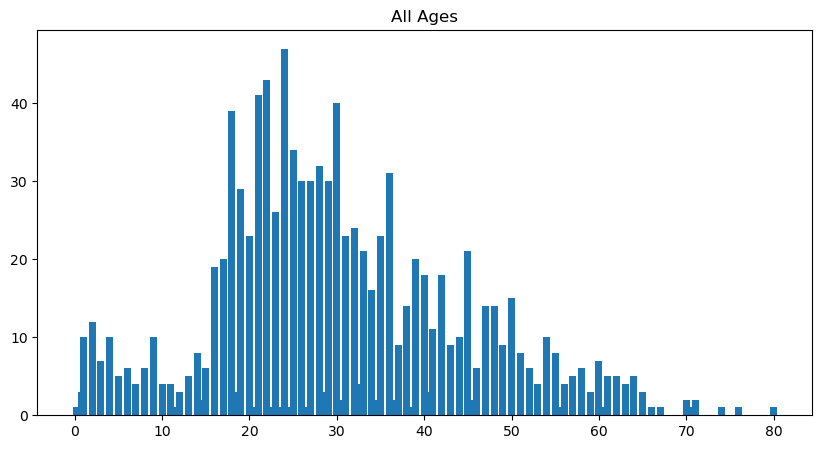

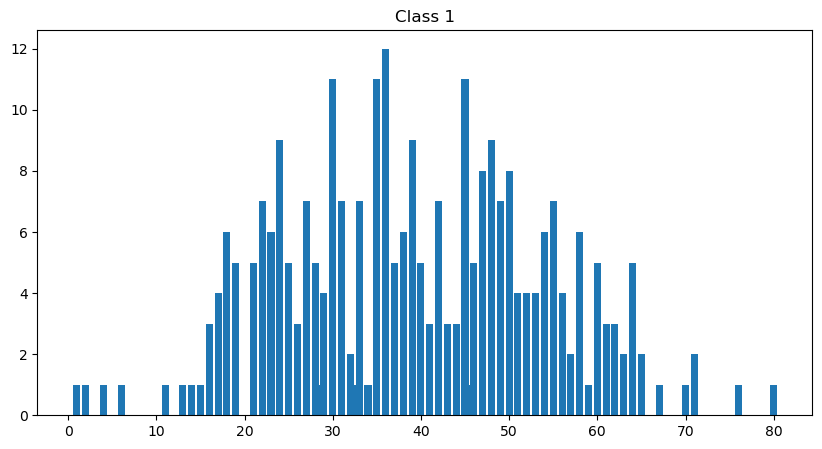

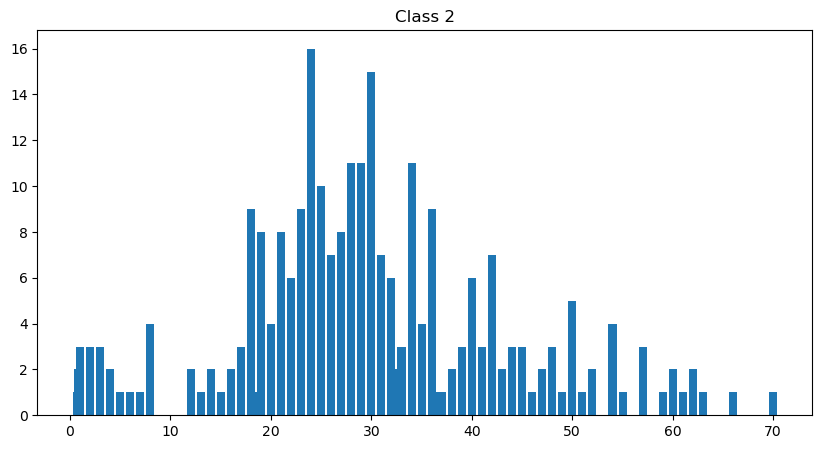

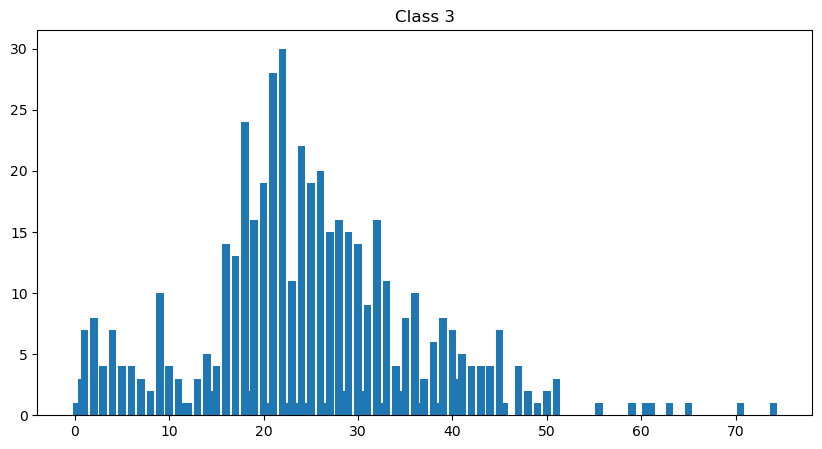

         Age
Pclass      
1       39.0
2       29.0
3       24.0


In [33]:
import matplotlib.pyplot as plt

# Count all ages
y = combined_data['Age'].value_counts()
x = y.index.values

# Plot all ages
plt.figure(figsize=(10,5))
plt.bar(x, y)

plt.title('All Ages')

plt.show()


# Select only Pclass and Age columns
class_age = combined_data[['Pclass', 'Age']]

# Loop through classes 1, 2, and 3
for i in range(1, 4):

    plt.figure(figsize=(10,5))

    plt.title('Class ' + str(i))

    # Filter ages for the current class
    y = class_age[class_age['Pclass'] == i]['Age'].value_counts()

    # Get age values
    x = y.index.values

    # Plot bar chart
    plt.bar(x, y)

    plt.show()


medians = class_age.groupby("Pclass").median()
print(medians)

In [34]:
for i in range(3):
    idx = np.where((combined_data["Pclass"] == i + 1) &(combined_data["Age"].isnull()))[0]
    combined_data.loc[idx, "Age"] = medians.values[i][0]

combined_data.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,NaN,Q
6,7,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


Median: 8.05


/var/folders/_5/b838qxtn42nckqn8mh173y2w0000gn/T/ipykernel_69290/1590098767.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_data["Fare"].fillna(sim_fares.median(), inplace=True)


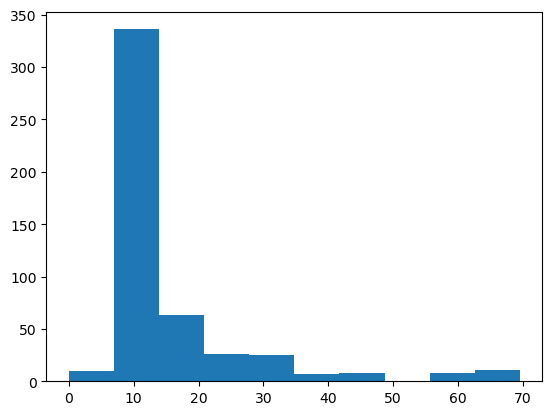

In [35]:
display(combined_data[combined_data["Fare"].isnull()])


sim_fares = combined_data[(combined_data["Pclass"]== 3) &(combined_data["Embarked"]== "S")]["Fare"]

print("Median:", sim_fares.median())

plt.hist(sim_fares)
plt.plot()

combined_data["Fare"].fillna(sim_fares.median(), inplace=True)

In [36]:
display(combined_data[combined_data["Embarked"].isnull()])


sim_emb = combined_data[(combined_data["Pclass"]== 1) & (combined_data["Fare"]>= 70)&(combined_data["Fare"]<= 90)]["Embarked"]


combined_data["Embarked"].fillna("C", inplace=True)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


/var/folders/_5/b838qxtn42nckqn8mh173y2w0000gn/T/ipykernel_69290/4278260950.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_data["Embarked"].fillna("C", inplace=True)


In [37]:
combined_data["Cabin"].fillna("M",inplace = True)
combined_data["Cabin"]= combined_data["Cabin"].str[0]
print(combined_data["Cabin"].value_counts())




Cabin
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64


/var/folders/_5/b838qxtn42nckqn8mh173y2w0000gn/T/ipykernel_69290/3823392388.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_data["Cabin"].fillna("M",inplace = True)


In [38]:
print(combined_data.isnull().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [39]:
print(combined_data.nunique())

PassengerId    1309
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin             9
Embarked          3
dtype: int64


In [40]:
names = combined_data['Name']

last_names = []
titles = []
first_names = []

for name in names:
    if ', ' not in name:
        last_names.append('')
    else:
        last, name = name.split(', ', 1)
        last_names.append(last)
    
    if '. ' not in name:
        titles.append('')
    else:
        title, first = name.split('. ', 1)
        titles.append(title)
        first_names.append(first)

last_names = np.array(last_names)
titles = np.array(titles)
first_names = np.array(first_names)

print('\n')
print(np.unique(titles, return_counts=True))

idx = np.where(np.isin(titles,["Capt","Major","Col"]))
titles[idx] = "Military"

idx = np.where(np.isin(titles,["Don","Dona","Jonkheer","Lady", "Sir","Master","The Countess"]))
titles[idx] = "Nobility"


idx = np.where(np.isin(titles,["Miss","Mlle","Ms"]))
titles[idx] = "Ms"

idx = np.where(np.isin(titles,["Mrs","Mme"]))
titles[idx] = "Mrs"

print('\n')
print(np.unique(titles, return_counts=True))

combined_data["Title"] = titles

display(combined_data)



(array(['Capt', 'Col', 'Don', 'Dona', 'Dr', 'Jonkheer', 'Lady', 'Major',
       'Master', 'Miss', 'Mlle', 'Mme', 'Mr', 'Mrs', 'Ms', 'Rev', 'Sir',
       'the Countess'], dtype='<U12'), array([  1,   4,   1,   1,   8,   1,   1,   2,  61, 260,   2,   1, 757,
       197,   2,   8,   1,   1]))


(array(['Dr', 'Military', 'Mr', 'Mrs', 'Ms', 'Nobility', 'Rev',
       'the Countess'], dtype='<U12'), array([  8,   7, 757, 198, 264,  66,   8,   1]))


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr


In [41]:
print(combined_data["Age"].min(),combined_data["Age"].max() )

bins =np.array([0,10,20,30,40,50,60,70,80])

combined_data["Age_Bin"] = pd.cut(combined_data["Age"], bins)

combined_data.head()

0.17 80.0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]"


In [42]:
ticket_dict = dict(combined_data["Ticket"].value_counts())

combined_data["tikt_count"] = combined_data["Ticket"].map(ticket_dict)

display(combined_data)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,tikt_count
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1


0.0 128.0823


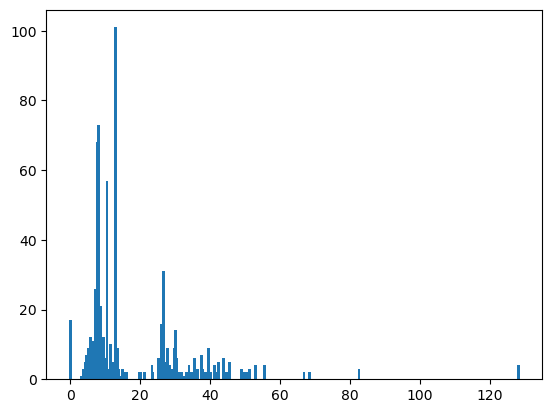

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,tikt_count,Fare_per_Ticket,Fare_Bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1,7.25000,"(0, 20]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2,35.64165,"(20, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1,7.92500,"(0, 20]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2,26.55000,"(20, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1,8.05000,"(0, 20]"


In [43]:
combined_data["Fare_per_Ticket"] = combined_data["Fare"]/combined_data["tikt_count"]

plt.bar(combined_data["Fare_per_Ticket"].value_counts().index.values, combined_data["Fare_per_Ticket"].value_counts())

print(combined_data["Fare_per_Ticket"].min(),combined_data["Fare_per_Ticket"].max() )

bins =np.array([0,20,40,60,80, 150])

combined_data["Fare_Bin"] = pd.cut(combined_data["Fare_per_Ticket"], bins)

plt.show()
combined_data.head()

In [44]:
combined_data["Num_Family"] = combined_data["SibSp"] + combined_data["Parch"] + 1

display(combined_data)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,tikt_count,Fare_per_Ticket,Fare_Bin,Num_Family
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1,7.250000,"(0, 20]",2
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2,35.641650,"(20, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1,7.925000,"(0, 20]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2,26.550000,"(20, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1,8.050000,"(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3,36.300000,"(20, 40]",1
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1,7.250000,"(0, 20]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]",1


In [45]:
combined_data.drop(["Name","Age","Ticket","Fare","tikt_count","Fare_per_Ticket"], axis =1 , inplace = True)

combined_data.head()

,PassengerId,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_Bin,Num_Family
0,1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
1,2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
2,3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
3,4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
4,5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1


In [46]:
print(combined_data.nunique())

PassengerId    1309
Pclass            3
Sex               2
SibSp             7
Parch             8
Cabin             9
Embarked          3
Title             8
Age_Bin           8
Fare_Bin          5
Num_Family        9
dtype: int64


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [48]:
combined_data.set_index("PassengerId", inplace = True)
display(combined_data)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_Bin,Num_Family
PassengerId,,,,,,,,,,
1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...
1305,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1
1306,1,female,0,0,C,C,Nobility,"(30, 40]","(20, 40]",1
1307,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1


In [50]:
label_enc = combined_data.copy()

label_enc = label_enc.astype(str)

label_enc = label_enc.apply(LabelEncoder().fit_transform)

display(label_enc)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_Bin,Num_Family
PassengerId,,,,,,,,,,
1,2,1,1,0,7,2,2,2,0,2
2,0,0,1,0,2,0,3,3,1,2
3,2,0,0,0,7,2,4,2,0,0
4,0,0,1,0,2,2,3,3,1,2
5,2,1,0,0,7,2,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...
1305,2,1,0,0,7,2,2,2,0,0
1306,0,0,0,0,2,0,5,3,1,0
1307,2,1,0,0,7,2,2,3,0,0


In [53]:
one_hot = label_enc.copy()

one_hot = pd.get_dummies(one_hot, columns=["Sex","Embarked","Title"])

display(one_hot)

,Pclass,SibSp,Parch,Cabin,Age_Bin,Fare_Bin,Num_Family,Sex_0,Sex_1,Embarked_0,Embarked_1,Embarked_2,Title_0,Title_1,Title_2,Title_3,Title_4,Title_5,Title_6,Title_7
PassengerId,,,,,,,,,,,,,,,,,,,,
1,2,1,0,7,2,0,2,False,True,False,False,True,False,False,True,False,False,False,False,False
2,0,1,0,2,3,1,2,True,False,True,False,False,False,False,False,True,False,False,False,False
3,2,0,0,7,2,0,0,True,False,False,False,True,False,False,False,False,True,False,False,False
4,0,1,0,2,3,1,2,True,False,False,False,True,False,False,False,True,False,False,False,False
5,2,0,0,7,3,0,0,False,True,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,2,0,0,7,2,0,0,False,True,False,False,True,False,False,True,False,False,False,False,False
1306,0,0,0,2,3,1,0,True,False,True,False,False,False,False,False,False,False,True,False,False
1307,2,0,0,7,3,0,0,False,True,False,False,True,False,False,True,False,False,False,False,False


In [58]:
X = one_hot.loc[train_idx].values
y = survived.values

scaler = MinMaxScaler()

scaler.fit(X)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=0
)

print(
    X_train.shape,
    X_test.shape,
    y_train.shape,
    y_test.shape
)

(712, 20) (179, 20) (712,) (179,)


In [59]:
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train,y_train).score(X_test,y_test)

0.8100558659217877

In [60]:
params = {
    'criterion': ['gini', 'entropy'],
    
    'n_estimators': [20, 50, 100, 200, 300, 400, 500, 800, 1000],
    
    'max_depth': np.arange(3, 50),
    
    'min_samples_split': np.arange(1, 1000),
    
    'max_features': ['sqrt', 'log2'],
    
    'max_samples': np.linspace(0.1, 0.9, 10)
}

rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=0),
    params,
    scoring='accuracy',
    random_state=0,
    cv=5
)

rand_search.fit(X_train, y_train)

rand_params = rand_search.best_params_

print(rand_params, '\n')

print('Train Acc:', rand_search.best_score_)

preds = rand_search.predict(X_test)

print('Test Acc:', accuracy_score(preds, y_test))

{'n_estimators': 200, 'min_samples_split': np.int64(16), 'max_samples': np.float64(0.6333333333333333), 'max_features': 'sqrt', 'max_depth': np.int64(49), 'criterion': 'gini'} 

Train Acc: 0.8314488328572835
Test Acc: 0.8100558659217877


In [61]:
n_estimators = np.linspace(
    rand_params['n_estimators'] - 10,
    rand_params['n_estimators'] + 10,
    3
).astype(int)

min_samples_split = np.arange(
    rand_params['min_samples_split'] - 3,
    rand_params['min_samples_split'] + 3
).astype(int)

max_samples = np.linspace(
    rand_params['max_samples'] - .05,
    rand_params['max_samples'] + .05,
    6
)

max_depth = np.arange(
    rand_params['max_depth'] - 5,
    rand_params['max_depth'] + 5
).astype(int)

params = {
    'criterion': [rand_params['criterion']],
    
    'n_estimators': n_estimators,
    
    'max_depth': max_depth,
    
    'min_samples_split': min_samples_split,
    
    'max_features': [rand_params['max_features']],
    
    'max_samples': max_samples
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=0),
    params,
    scoring='accuracy',
    cv=5
)

grid_search.fit(X_train, y_train)

grid_params = grid_search.best_params_

print(grid_params, '\n')

print('Train Acc:', grid_search.best_score_)

preds = grid_search.predict(X_test)

print('Test Acc:', accuracy_score(preds, y_test))

{'criterion': 'gini', 'max_depth': np.int64(44), 'max_features': 'sqrt', 'max_samples': np.float64(0.6033333333333333), 'min_samples_split': np.int64(17), 'n_estimators': np.int64(200)} 

Train Acc: 0.8328572835615089
Test Acc: 0.8268156424581006


In [62]:
from sklearn.ensemble import AdaBoostClassifier

In [63]:
clf = AdaBoostClassifier(random_state=0)
clf.fit(X_train, y_train).score(X_test,y_test)

0.7988826815642458

In [64]:
params = {
    'n_estimators': [50,100,200,300,400,500,800,100],
    
    'learning_rate': [1.0, 0.1, 0.01, 0.001]
}

rand_search = RandomizedSearchCV(
    AdaBoostClassifier(random_state=0),
    params,
    scoring='accuracy',
    random_state=0,
    cv=5
)

rand_search.fit(X_train, y_train)

rand_params = rand_search.best_params_

print(rand_params, '\n')

print('Train Acc:', rand_search.best_score_)

preds = rand_search.predict(X_test)

print('Test Acc:', accuracy_score(preds, y_test))

{'n_estimators': 200, 'learning_rate': 1.0} 

Train Acc: 0.8258642765685019
Test Acc: 0.8100558659217877


In [65]:
n_estimators = np.linspace(
    rand_params['n_estimators'] - 50,
    rand_params['n_estimators'] + 50,
    3
).astype(int)

learning_rate = np.linspace(
    rand_params['learning_rate'] * 0.9,
    rand_params['learning_rate'] * 1.1,
    3
)

params = {
    'n_estimators': n_estimators,
    'learning_rate': learning_rate
}

grid_search = GridSearchCV(
    AdaBoostClassifier(random_state=0),
    params,
    scoring='accuracy',
    cv=5
)

grid_search.fit(X_train, y_train)

grid_params = grid_search.best_params_

print(grid_params, '\n')

print('Train Acc:', grid_search.best_score_)

preds = grid_search.predict(X_test)

print('Test Acc:', accuracy_score(preds, y_test))

{'learning_rate': np.float64(1.0), 'n_estimators': np.int64(250)} 

Train Acc: 0.8272628779671033
Test Acc: 0.8100558659217877
